## STEP 1 — IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)

import joblib

print('===================================')
print('ALL IMPORTS SUCCESSFUL')
print('===================================')

ALL IMPORTS SUCCESSFUL


In [2]:
# Install extra libraries if needed
!pip install xgboost catboost --quiet

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print('XGBoost and CatBoost ready.')

XGBoost and CatBoost ready.


## STEP 2 — LOAD DATA

In [3]:
df = pd.read_csv(
    'poseidon_wealth_v3.csv',
    encoding='latin1'
)

print('===================================')
print('DATA LOADED')
print('===================================')
print(f'Shape: {df.shape}')
print(f'\nFirst 5 Rows:')
df.head()

DATA LOADED
Shape: (10000, 16)

First 5 Rows:


,Client ID,Client Name,Age Bucket,Gender,City,Education Level,Professional Qualification,Occupation,Income Type,Annual Income Bucket,Debt Bucket,Net Worth Bucket,Risk Appetite,Persona Category,Cash Flow Status,Lifecycle Stage
0,C001,Azad Wali,20Â25,Male,Gurugram,Secondary School,MD,Consultant,Business,?1Â1.5Cr,?2Â4L,?8Â8.5Cr,Moderately Aggressive,Student Without Income,Negative,Student
1,C002,Drishya Mani,35Â40,Male,Noida,Post Graduate,NaN,Domestic Worker,Daily Wage,?1Â1.5Cr,?12Â14L,?25Â30L,Moderately Aggressive,Defence Professional,Positive,Student
2,C003,Aayush Gokhale,50Â55,Male,Ahmedabad,Undergraduate,B.Tech,Driver,Interest & Passive Income,?5Â10L,?2Â4L,?2Â2.5Cr,Moderately Conservative,Retired Professional,Negative,Pre-Retirement
3,C004,Nayantara Ganesh,20Â25,Female,Lucknow,Post Graduate,CFA,Teacher,Business,?1Â1.5Cr,?8Â10L,?9Â9.5Cr,Aggressive,Freelancer,Positive,Pre-Retirement
4,C005,Uthkarsh Chahal,25Â30,Male,Mumbai,Doctorate,MD,Project Manager,Business,?15Â20L,?2Â4L,?2Â2.5Cr,Moderately Aggressive,Software Professional,Positive,Mid Career


## STEP 3 — CLEAN DATA

In [4]:
print('Shape Before Cleaning:', df.shape)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Drop ID columns — not useful for prediction
drop_cols = ['Client ID', 'Client Name']
for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Fill missing professional qualification
df['Professional Qualification'] = df['Professional Qualification'].fillna('Unknown')

print('Shape After Cleaning:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())

Shape Before Cleaning: (10000, 16)
Shape After Cleaning: (10000, 14)

Missing Values:
Age Bucket                    0
Gender                        0
City                          0
Education Level               0
Professional Qualification    0
Occupation                    0
Income Type                   0
Annual Income Bucket          0
Debt Bucket                   0
Net Worth Bucket              0
Risk Appetite                 0
Persona Category              0
Cash Flow Status              0
Lifecycle Stage               0
dtype: int64


## STEP 4 — EXPLORATORY DATA ANALYSIS (EDA)

TARGET COLUMN DISTRIBUTION

Counts:
Risk Appetite
Moderately Aggressive      3272
Moderate                   2650
Moderately Conservative    1422
Conservative               1378
Aggressive                 1278
Name: count, dtype: int64

Percentage:
Risk Appetite
Moderately Aggressive      32.72
Moderate                   26.50
Moderately Conservative    14.22
Conservative               13.78
Aggressive                 12.78
Name: proportion, dtype: float64


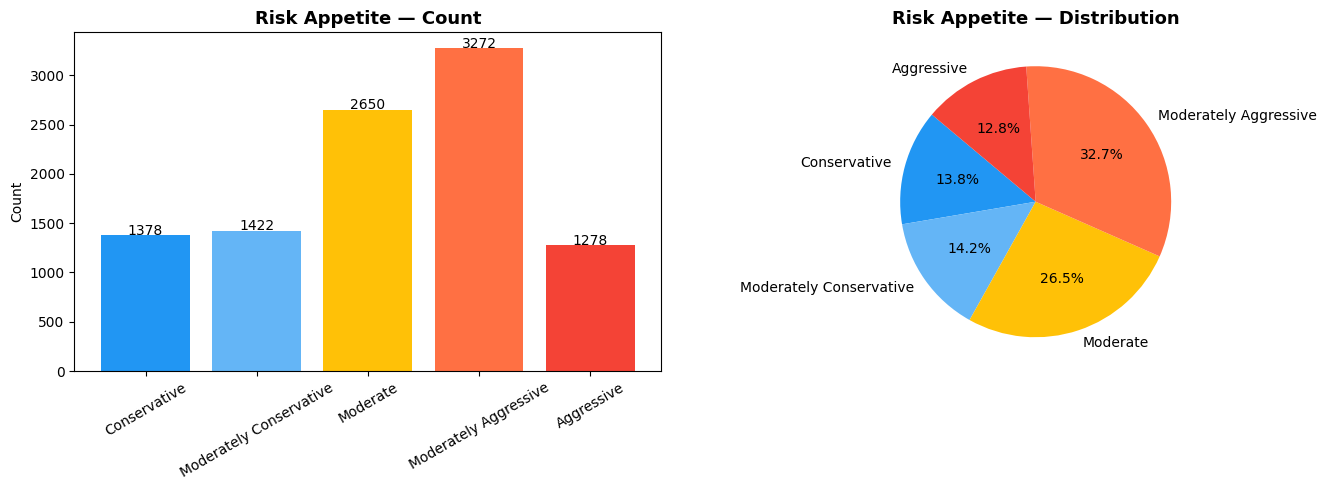

Plot saved: eda_target_distribution.png


In [5]:
print('===================================')
print('TARGET COLUMN DISTRIBUTION')
print('===================================')

risk_counts = df['Risk Appetite'].value_counts()
risk_pct    = df['Risk Appetite'].value_counts(normalize=True) * 100

print('\nCounts:')
print(risk_counts)
print('\nPercentage:')
print(risk_pct.round(2))

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Conservative', 'Moderately Conservative', 'Moderate', 'Moderately Aggressive', 'Aggressive']
colors = ['#2196F3', '#64B5F6', '#FFC107', '#FF7043', '#F44336']

# Bar chart
ax = axes[0]
vals = [risk_counts.get(o, 0) for o in order]
ax.bar(order, vals, color=colors)
ax.set_title('Risk Appetite — Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(vals):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)

# Pie chart
pct_vals = [risk_pct.get(o, 0) for o in order]
axes[1].pie(pct_vals, labels=order, colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Risk Appetite — Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: eda_target_distribution.png')

In [6]:
# Column type summary
categorical_cols_eda = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols_eda     = df.select_dtypes(exclude=['object']).columns.tolist()

print(f'Categorical Columns ({len(categorical_cols_eda)}): {categorical_cols_eda}')
print(f'\nNumeric Columns ({len(numeric_cols_eda)}): {numeric_cols_eda}')

print('\n--- Unique values per categorical column ---')
for col in categorical_cols_eda:
    print(f'{col}: {df[col].nunique()} unique → {df[col].unique()[:5]}...')

Categorical Columns (14): ['Age Bucket', 'Gender', 'City', 'Education Level', 'Professional Qualification', 'Occupation', 'Income Type', 'Annual Income Bucket', 'Debt Bucket', 'Net Worth Bucket', 'Risk Appetite', 'Persona Category', 'Cash Flow Status', 'Lifecycle Stage']

Numeric Columns (0): []

--- Unique values per categorical column ---
Age Bucket: 9 unique → ['20Â\x9625' '35Â\x9640' '50Â\x9655' '25Â\x9630' '45Â\x9650']...
Gender: 2 unique → ['Male' 'Female']...
City: 28 unique → ['Gurugram' 'Noida' 'Ahmedabad' 'Lucknow' 'Mumbai']...
Education Level: 6 unique → ['Secondary School' 'Post Graduate' 'Undergraduate' 'Doctorate' 'Graduate']...
Professional Qualification: 36 unique → ['MD' 'Unknown' 'B.Tech' 'CFA' 'B.Com']...
Occupation: 74 unique → ['Consultant' 'Domestic Worker' 'Driver' 'Teacher' 'Project Manager']...
Income Type: 17 unique → ['Business' 'Daily Wage' 'Interest & Passive Income' 'No Income'
 'Family Supported']...
Annual Income Bucket: 13 unique → ['?1Â\x961.5Cr' '?5Â\

## STEP 5 — DEFINE FEATURES & TARGET
> ⚠️ We use the **original Risk Appetite labels from the CSV** — we do NOT overwrite them with rules. That was data leakage.

In [7]:
target_column = 'Risk Appetite'

X = df.drop(target_column, axis=1)
y = df[target_column]

print('===================================')
print('FEATURES & TARGET')
print('===================================')
print(f'X Shape: {X.shape}')
print(f'y Shape: {y.shape}')
print(f'\nUnique Classes in y:')
print(y.unique())
print(f'\nClass Count:')
print(y.value_counts())

FEATURES & TARGET
X Shape: (10000, 13)
y Shape: (10000,)

Unique Classes in y:
['Moderately Aggressive' 'Moderately Conservative' 'Aggressive' 'Moderate'
 'Conservative']

Class Count:
Risk Appetite
Moderately Aggressive      3272
Moderate                   2650
Moderately Conservative    1422
Conservative               1378
Aggressive                 1278
Name: count, dtype: int64


## STEP 6 — ENCODE TARGET COLUMN

In [8]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('===================================')
print('LABEL ENCODING')
print('===================================')
print('\nLabel Mapping:')
for idx, label in enumerate(label_encoder.classes_):
    print(f'  {label} --> {idx}')

print(f'\nEncoded sample: {y_encoded[:10]}')

LABEL ENCODING

Label Mapping:
  Aggressive --> 0
  Conservative --> 1
  Moderate --> 2
  Moderately Aggressive --> 3
  Moderately Conservative --> 4

Encoded sample: [3 3 4 0 3 2 2 3 1 3]


## STEP 7 — TRAIN / TEST SPLIT
> ✅ We split BEFORE any feature engineering. This is the correct order.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded     # keeps class balance in both splits
)

print('===================================')
print('TRAIN / TEST SPLIT')
print('===================================')
print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')

# Verify class balance is preserved
unique, counts = np.unique(y_train, return_counts=True)
print('\nClass distribution in training set:')
for u, c in zip(unique, counts):
    print(f'  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)')

TRAIN / TEST SPLIT
X_train: (8000, 13)
X_test : (2000, 13)
y_train: (8000,)
y_test : (2000,)

Class distribution in training set:
  Aggressive: 1022 (12.8%)
  Conservative: 1102 (13.8%)
  Moderate: 2120 (26.5%)
  Moderately Aggressive: 2618 (32.7%)
  Moderately Conservative: 1138 (14.2%)


## STEP 8 — FEATURE ENGINEERING (Custom Transformer)
> ✅ This transformer is fitted only on training data and then applied to test data — no leakage.

In [10]:
class FinancialFeatureEngineering(BaseEstimator, TransformerMixin):
    """
    Converts income/debt/net-worth bucket strings to numeric values
    and engineers meaningful financial ratio features.
    Inherits from sklearn's base classes so it works inside a Pipeline.
    """

    def __init__(self):
        self.income_mapping = {
            '₹0-5L':     250_000,
            '₹5-10L':    750_000,
            '₹10-15L':  1_250_000,
            '₹15-20L':  1_750_000,
            '₹20-25L':  2_250_000,
            '₹25-30L':  2_750_000,
            '₹35-40L':  3_750_000,
            '₹50-55L':  5_250_000,
            '₹1-1.5Cr': 12_500_000,
            '₹3Cr+':    30_000_000,
        }
        self.debt_mapping = {
            'Not Applicable': 0,
            '₹2-4L':     300_000,
            '₹4-6L':     500_000,
            '₹6-8L':     700_000,
            '₹8-10L':    900_000,
            '₹10-12L':  1_100_000,
            '₹12-14L':  1_300_000,
            '₹14-16L':  1_500_000,
            '₹18-20L':  1_900_000,
            '₹20-25L':  2_250_000,
            '₹30-35L':  3_250_000,
        }
        self.networth_mapping = {
            '₹0-5L':       250_000,
            '₹10-15L':    1_250_000,
            '₹15-20L':    1_750_000,
            '₹25-30L':    2_750_000,
            '₹50-55L':    5_250_000,
            '₹1-1.5Cr':  12_500_000,
            '₹2-2.5Cr':  22_500_000,
            '₹3-3.5Cr':  32_500_000,
            '₹5-5.5Cr':  52_500_000,
            '₹8-8.5Cr':  82_500_000,
            '₹9-9.5Cr':  92_500_000,
            '₹20-20.5Cr':202_500_000,
            '₹25Cr+':   300_000_000,
        }

    def fit(self, X, y=None):
        # Nothing to learn from data — mappings are fixed
        return self

    def transform(self, X):
        X = X.copy()

        # --- Convert buckets to numbers ---
        X['income_numeric']   = X['Annual Income Bucket'].map(self.income_mapping).fillna(0)
        X['debt_numeric']     = X['Debt Bucket'].map(self.debt_mapping).fillna(0)
        X['networth_numeric'] = X['Net Worth Bucket'].map(self.networth_mapping).fillna(0)

        # --- Engineered features ---
        X['debt_to_income_ratio']      = X['debt_numeric'] / (X['income_numeric'] + 1)
        X['networth_minus_debt']       = X['networth_numeric'] - X['debt_numeric']
        X['financial_stability_score'] = X['networth_numeric'] + X['income_numeric'] - X['debt_numeric']
        X['savings_rate']              = (X['income_numeric'] - X['debt_numeric']) / (X['income_numeric'] + 1)
        X['wealth_to_debt_ratio']      = X['networth_numeric'] / (X['debt_numeric'] + 1)

        # --- Drop original bucket columns (already encoded above) ---
        X.drop(columns=['Annual Income Bucket', 'Debt Bucket', 'Net Worth Bucket'], inplace=True)

        return X


print('===================================')
print('FEATURE ENGINEERING CLASS DEFINED')
print('===================================')
print('New features that will be created:')
print('  1. income_numeric')
print('  2. debt_numeric')
print('  3. networth_numeric')
print('  4. debt_to_income_ratio')
print('  5. networth_minus_debt')
print('  6. financial_stability_score')
print('  7. savings_rate')
print('  8. wealth_to_debt_ratio')

FEATURE ENGINEERING CLASS DEFINED
New features that will be created:
  1. income_numeric
  2. debt_numeric
  3. networth_numeric
  4. debt_to_income_ratio
  5. networth_minus_debt
  6. financial_stability_score
  7. savings_rate
  8. wealth_to_debt_ratio


## STEP 9 — BUILD FULL PIPELINE
> The pipeline chains: FeatureEngineering → ColumnTransformer (scale numeric, encode categorical) → Model

In [11]:
# ---- After feature engineering, identify column types dynamically ----
# We apply the transformer to a sample to discover output column names
_sample = FinancialFeatureEngineering().fit_transform(X_train.copy())

categorical_columns = _sample.select_dtypes(include=['object']).columns.tolist()
numeric_columns     = _sample.select_dtypes(exclude=['object']).columns.tolist()

print(f'Numeric columns  ({len(numeric_columns)}): {numeric_columns}')
print(f'Categorical columns ({len(categorical_columns)}): {categorical_columns}')

# ---- Numeric transformer: impute → scale ----
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ---- Categorical transformer: impute → one-hot encode ----
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ---- Column transformer combines both ----
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_columns),
    ('cat', categorical_transformer, categorical_columns)
])

print('\nPreprocessor ready.')

Numeric columns  (8): ['income_numeric', 'debt_numeric', 'networth_numeric', 'debt_to_income_ratio', 'networth_minus_debt', 'financial_stability_score', 'savings_rate', 'wealth_to_debt_ratio']
Categorical columns (10): ['Age Bucket', 'Gender', 'City', 'Education Level', 'Professional Qualification', 'Occupation', 'Income Type', 'Persona Category', 'Cash Flow Status', 'Lifecycle Stage']

Preprocessor ready.


## STEP 10 — DEFINE MODELS

In [12]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree':          DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=200, random_state=42),
    'KNN':                    KNeighborsClassifier(n_neighbors=7),
    'SVM':                    SVC(class_weight='balanced', probability=True, random_state=42),
    'Naive Bayes':            GaussianNB(),
    'XGBoost':                XGBClassifier(eval_metric='mlogloss', n_estimators=200, random_state=42, n_jobs=-1),
    'CatBoost':               CatBoostClassifier(verbose=0, iterations=200, random_seed=42)
}

print('===================================')
print('MODELS READY')
print('===================================')
for name in models:
    print(f'  {name}')

MODELS READY
  Logistic Regression
  Decision Tree
  Random Forest
  Gradient Boosting
  KNN
  SVM
  Naive Bayes
  XGBoost
  CatBoost


## STEP 11 — TRAIN ALL MODELS & COMPARE

In [23]:
best_accuracy  = 0
best_f1        = 0
best_model     = None
best_model_name = ''
results        = []

print('===================================')
print('TRAINING ALL MODELS')
print('===================================')

for name, algorithm in models.items():
    print(f'\nTraining: {name} ...', end=' ')

    # Full pipeline: feature engineering → preprocessing → model
    model_pipeline = Pipeline(steps=[
        ('feature_engineering', FinancialFeatureEngineering()),
        ('preprocessor',        preprocessor),
        ('classifier',          algorithm)
    ])

    # Train
    model_pipeline.fit(X_train, y_train)

    # Predict
    y_pred = model_pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average='weighted')

    print(f'Accuracy: {accuracy*100:.2f}%  |  Weighted F1: {f1:.4f}')

    results.append({'Model': name, 'Accuracy': accuracy, 'Weighted F1': f1})

    # Track best by weighted F1 (better than accuracy for multi-class)
    if f1 > best_f1:
        best_f1         = f1
        best_accuracy   = accuracy
        best_model      = model_pipeline
        best_model_name = name

# ---- Results table ----
results_df = pd.DataFrame(results).sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print('\n===================================')
print('MODEL COMPARISON')
print('===================================')
print(results_df.to_string(index=False))

print(f'\nBest Model : {best_model_name}')
print(f'Accuracy   : {best_accuracy*100:.2f}%')
print(f'Weighted F1: {best_f1:.4f}')

TRAINING ALL MODELS

Training: Logistic Regression ... Accuracy: 47.95%  |  Weighted F1: 0.4636

Training: Decision Tree ... Accuracy: 44.30%  |  Weighted F1: 0.4458

Training: Random Forest ... Accuracy: 56.60%  |  Weighted F1: 0.5015

Training: Gradient Boosting ... Accuracy: 55.75%  |  Weighted F1: 0.5001

Training: KNN ... Accuracy: 48.05%  |  Weighted F1: 0.4623

Training: SVM ... Accuracy: 50.00%  |  Weighted F1: 0.4532

Training: Naive Bayes ... Accuracy: 39.10%  |  Weighted F1: 0.3710

Training: XGBoost ... Accuracy: 52.10%  |  Weighted F1: 0.4963

Training: CatBoost ... Accuracy: 55.40%  |  Weighted F1: 0.5106

MODEL COMPARISON
              Model  Accuracy  Weighted F1
           CatBoost    0.5540     0.510577
      Random Forest    0.5660     0.501482
  Gradient Boosting    0.5575     0.500109
            XGBoost    0.5210     0.496337
Logistic Regression    0.4795     0.463641
                KNN    0.4805     0.462291
                SVM    0.5000     0.453242
      Decis

## STEP 12 — MODEL COMPARISON CHART

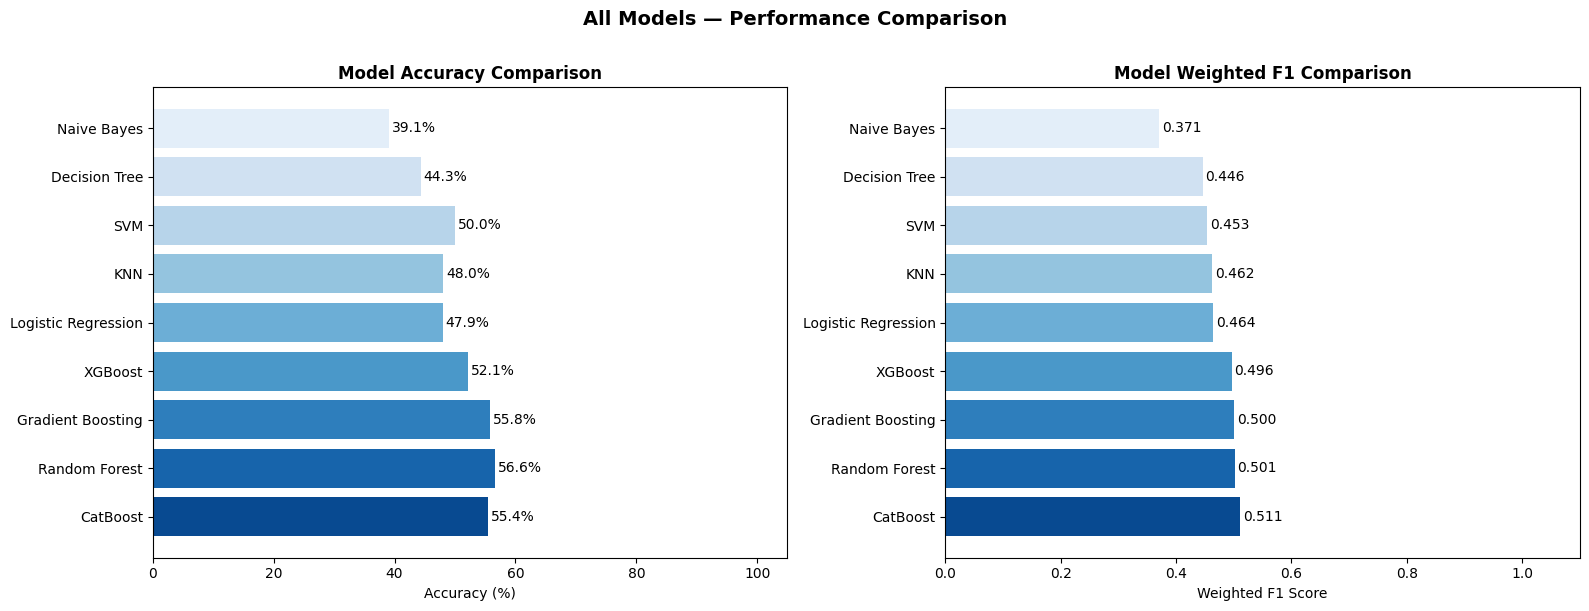

Plot saved: model_comparison.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette('Blues_r', len(results_df))

# Accuracy bar
axes[0].barh(results_df['Model'], results_df['Accuracy'] * 100, color=palette)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_xlim(0, 105)
for i, v in enumerate(results_df['Accuracy'] * 100):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center')

# Weighted F1 bar
axes[1].barh(results_df['Model'], results_df['Weighted F1'], color=palette)
axes[1].set_xlabel('Weighted F1 Score')
axes[1].set_title('Model Weighted F1 Comparison', fontweight='bold')
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(results_df['Weighted F1']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.suptitle('All Models — Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: model_comparison.png')

## STEP 13 — CROSS VALIDATION ON BEST MODEL
> Cross-validation gives a more honest accuracy estimate than a single train/test split.

In [25]:
print('===================================')
print(f'CROSS VALIDATION — {best_model_name}')
print('===================================')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,              # full dataset (CV handles splits internally)
    y_encoded,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f'\nCV Scores (5 folds): {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Mean Accuracy      : {cv_scores.mean()*100:.2f}%')
print(f'Std Dev            : ± {cv_scores.std()*100:.2f}%')
print('\n(If Mean CV Accuracy is close to Test Accuracy, the model is NOT overfitting — good!)')

CROSS VALIDATION — CatBoost

CV Scores (5 folds): ['54.45%', '54.55%', '55.90%', '54.00%', '54.80%']
Mean Accuracy      : 54.74%
Std Dev            : ± 0.64%

(If Mean CV Accuracy is close to Test Accuracy, the model is NOT overfitting — good!)


## STEP 14 — DETAILED EVALUATION OF BEST MODEL

In [16]:
y_pred_best = best_model.predict(X_test)

class_names = label_encoder.classes_

print('===================================')
print(f'CLASSIFICATION REPORT — {best_model_name}')
print('===================================')
print(classification_report(y_test, y_pred_best, target_names=class_names))

CLASSIFICATION REPORT — CatBoost
                         precision    recall  f1-score   support

             Aggressive       0.34      0.06      0.11       256
           Conservative       0.42      0.81      0.56       276
               Moderate       0.60      0.78      0.67       530
  Moderately Aggressive       0.68      0.64      0.66       654
Moderately Conservative       0.32      0.13      0.18       284

               accuracy                           0.55      2000
              macro avg       0.47      0.48      0.44      2000
           weighted avg       0.53      0.55      0.51      2000



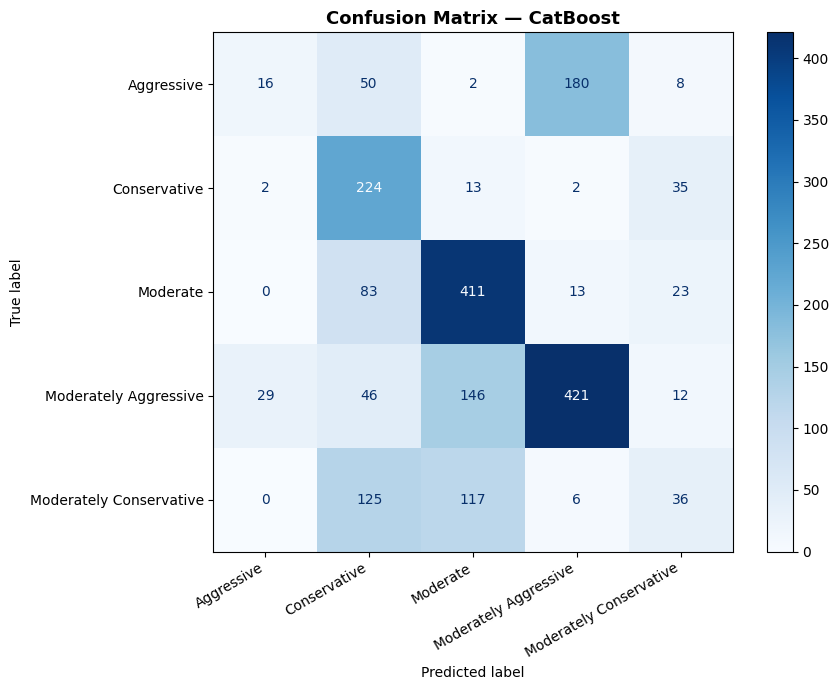

Plot saved: confusion_matrix_best.png


In [17]:
# ---- Confusion Matrix ----
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=class_names,
    cmap='Blues',
    ax=ax
)

ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: confusion_matrix_best.png')

## STEP 15 — HYPERPARAMETER TUNING (Best Model)
> We tune only the best model to squeeze out more performance. Uses RandomizedSearchCV (faster than GridSearch).

In [26]:
print(f'Tuning: {best_model_name}')
print('This may take a few minutes...\n')

# ---- Param grids for each model type ----
param_grids = {
    'Random Forest': {
        'classifier__n_estimators':  [100, 200, 300, 500],
        'classifier__max_depth':     [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__max_features':  ['sqrt', 'log2']
    },
    'XGBoost': {
        'classifier__n_estimators':  [100, 200, 300],
        'classifier__max_depth':     [3, 5, 7, 9],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__subsample':     [0.7, 0.8, 1.0]
    },
    'CatBoost': {
        'classifier__iterations':    [100, 200, 300],
        'classifier__depth':         [4, 6, 8, 10],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__l2_leaf_reg':   [1, 3, 5, 7]
    },
    'Gradient Boosting': {
        'classifier__n_estimators':  [100, 200, 300],
        'classifier__max_depth':     [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__subsample':     [0.7, 0.8, 1.0]
    },
    'Logistic Regression': {
        'classifier__C':             [0.01, 0.1, 1, 10, 100],
        'classifier__solver':        ['lbfgs', 'saga'],
        'classifier__penalty':       ['l2', None]
    },
    'SVM': {
        'classifier__C':             [0.1, 1, 10],
        'classifier__kernel':        ['rbf', 'linear'],
        'classifier__gamma':         ['scale', 'auto']
    },
    'KNN': {
        'classifier__n_neighbors':   [3, 5, 7, 9, 11],
        'classifier__weights':       ['uniform', 'distance'],
        'classifier__metric':        ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'classifier__max_depth':     [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__criterion':     ['gini', 'entropy']
    },
    'Naive Bayes': {
        'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

param_grid = param_grids.get(best_model_name, {})

if param_grid:
    tuned_pipeline = Pipeline(steps=[
        ('feature_engineering', FinancialFeatureEngineering()),
        ('preprocessor',        preprocessor),
        ('classifier',          models[best_model_name])
    ])

    random_search = RandomizedSearchCV(
        estimator  = tuned_pipeline,
        param_distributions = param_grid,
        n_iter     = 20,
        cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring    = 'f1_weighted',
        n_jobs     = -1,
        random_state = 42,
        verbose    = 1
    )

    random_search.fit(X_train, y_train)

    tuned_model = random_search.best_estimator_

    y_pred_tuned = tuned_model.predict(X_test)
    tuned_acc = accuracy_score(y_test, y_pred_tuned)
    tuned_f1  = f1_score(y_test, y_pred_tuned, average='weighted')

    print('\n===================================')
    print('TUNING RESULTS')
    print('===================================')
    print(f'Best Params    : {random_search.best_params_}')
    print(f'\nBefore Tuning → Accuracy: {best_accuracy*100:.2f}%  |  F1: {best_f1:.4f}')
    print(f'After  Tuning → Accuracy: {tuned_acc*100:.2f}%  |  F1: {tuned_f1:.4f}')

    # Use tuned model as final
    final_model      = tuned_model
    final_model_name = best_model_name + ' (Tuned)'
else:
    print(f'No param grid defined for {best_model_name}. Using best model as-is.')
    final_model      = best_model
    final_model_name = best_model_name

Tuning: CatBoost
This may take a few minutes...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

TUNING RESULTS
Best Params    : {'classifier__learning_rate': 0.05, 'classifier__l2_leaf_reg': 1, 'classifier__iterations': 300, 'classifier__depth': 10}

Before Tuning → Accuracy: 55.40%  |  F1: 0.5106
After  Tuning → Accuracy: 57.30%  |  F1: 0.5133


## STEP 16 — FINAL MODEL EVALUATION

FINAL MODEL: CatBoost (Tuned)

Accuracy   : 57.30%
Weighted F1: 0.5133

--- Classification Report ---
                         precision    recall  f1-score   support

             Aggressive       0.53      0.03      0.06       256
           Conservative       0.42      0.91      0.57       276
               Moderate       0.61      0.80      0.69       530
  Moderately Aggressive       0.70      0.67      0.69       654
Moderately Conservative       0.38      0.08      0.13       284

               accuracy                           0.57      2000
              macro avg       0.53      0.50      0.43      2000
           weighted avg       0.57      0.57      0.51      2000



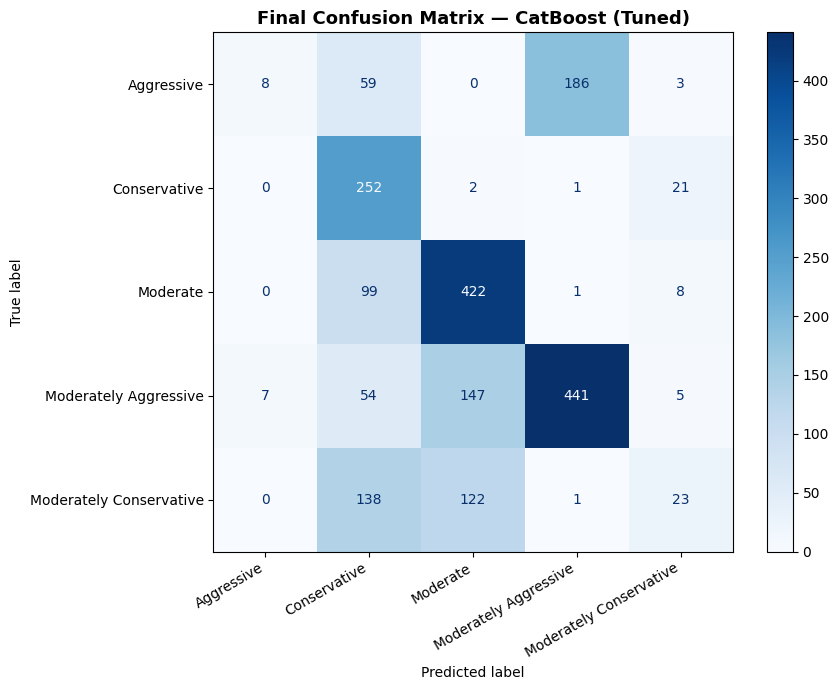

In [19]:
y_pred_final = final_model.predict(X_test)

print('===================================')
print(f'FINAL MODEL: {final_model_name}')
print('===================================')
print(f'\nAccuracy   : {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'Weighted F1: {f1_score(y_test, y_pred_final, average="weighted"):.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))

# Final confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=label_encoder.classes_,
    cmap='Blues', ax=ax
)
ax.set_title(f'Final Confusion Matrix — {final_model_name}', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 17 — FEATURE IMPORTANCE (if tree-based model)

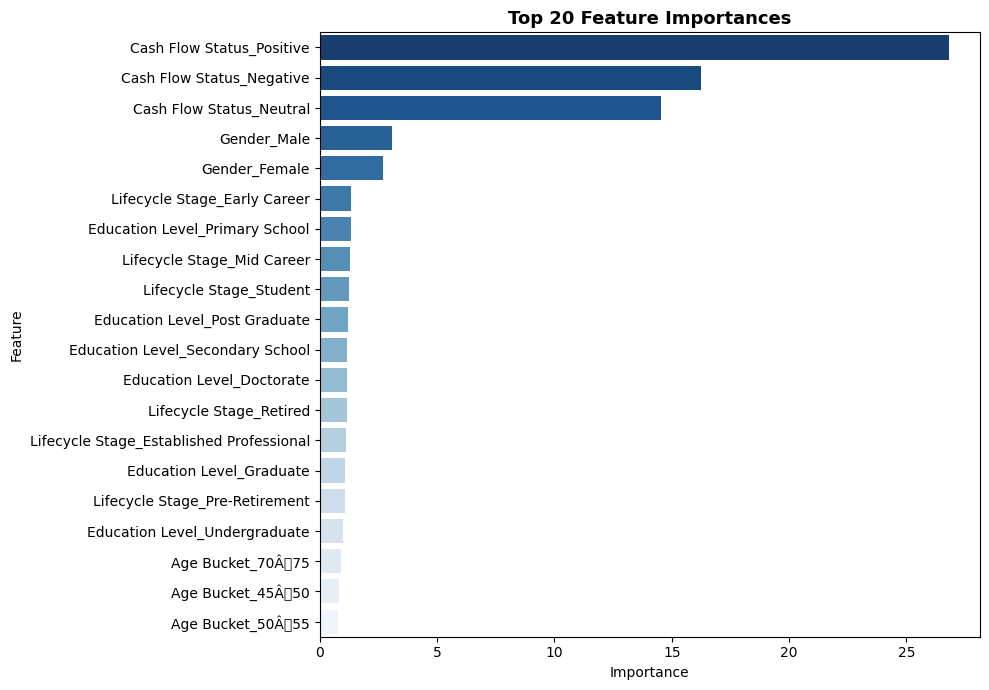

Plot saved: feature_importance.png

Top 10 Features:
                       Feature  Importance
     Cash Flow Status_Positive   26.791927
     Cash Flow Status_Negative   16.235833
      Cash Flow Status_Neutral   14.548490
                   Gender_Male    3.091255
                 Gender_Female    2.713927
  Lifecycle Stage_Early Career    1.351947
Education Level_Primary School    1.328482
    Lifecycle Stage_Mid Career    1.309791
       Lifecycle Stage_Student    1.260743
 Education Level_Post Graduate    1.201739


In [20]:
try:
    classifier_step = final_model.named_steps['classifier']
    importances = classifier_step.feature_importances_

    # Get feature names after preprocessing
    preprocessor_step = final_model.named_steps['preprocessor']
    num_feat_names = numeric_columns
    cat_feat_names = list(preprocessor_step
                         .named_transformers_['cat']
                         .named_steps['encoder']
                         .get_feature_names_out(categorical_columns))
    feature_names = num_feat_names + cat_feat_names

    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Blues_r')
    plt.title('Top 20 Feature Importances', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved: feature_importance.png')
    print('\nTop 10 Features:')
    print(feat_imp_df.head(10).to_string(index=False))

except AttributeError:
    print(f'{final_model_name} does not support feature_importances_. Skipping.')

## STEP 18 — SAVE FINAL MODEL

In [21]:
joblib.dump(final_model,    'best_model.pkl')
joblib.dump(label_encoder,  'label_encoder.pkl')

print('===================================')
print('MODEL SAVED SUCCESSFULLY')
print('===================================')
print('Saved Files:')
print('  1. best_model.pkl    — full pipeline (feature eng + preprocessor + model)')
print('  2. label_encoder.pkl — decodes numeric predictions back to class names')

MODEL SAVED SUCCESSFULLY
Saved Files:
  1. best_model.pkl    — full pipeline (feature eng + preprocessor + model)
  2. label_encoder.pkl — decodes numeric predictions back to class names


## STEP 19 — LOAD MODEL & PREDICT ON NEW CLIENT

In [22]:
loaded_model   = joblib.load('best_model(1).pkl')
loaded_encoder = joblib.load('label_encoder(1).pkl')

# ---- Sample new client (raw input — same format as original CSV) ----
sample_input = pd.DataFrame([{
    'Age Bucket':                '25-30',
    'Gender':                    'Male',
    'City':                      'Mumbai',
    'Education Level':           'Post Graduate',
    'Professional Qualification':'MBA',
    'Occupation':                'Software Engineer',
    'Income Type':               'Salary',
    'Persona Category':          'Professional',
    'Cash Flow Status':          'Positive',
    'Lifecycle Stage':           'Mid Career',
    'Annual Income Bucket':      '₹15-20L',
    'Debt Bucket':               '₹4-6L',
    'Net Worth Bucket':          '₹1-1.5Cr'
}])

# ---- Predict ----
prediction       = loaded_model.predict(sample_input)
predicted_label  = loaded_encoder.inverse_transform(prediction)[0]
prediction_proba = loaded_model.predict_proba(sample_input)[0]

print('===================================')
print('PREDICTION RESULT')
print('===================================')
print(f'\nPredicted Risk Appetite: {predicted_label}')
print('\nConfidence per class:')
for cls, prob in zip(loaded_encoder.classes_, prediction_proba):
    bar = '█' * int(prob * 30)
    print(f'  {cls:<30} {bar} {prob*100:.1f}%')

PREDICTION RESULT

Predicted Risk Appetite: Conservative

Confidence per class:
  Aggressive                     █ 5.6%
  Conservative                   ██████████████ 48.7%
  Moderate                       █████ 19.0%
  Moderately Aggressive          ███ 10.8%
  Moderately Conservative        ████ 15.9%


---
## 📊 Summary — What Good Accuracy Looks Like for This Problem

| Metric | Target for Production |
|---|---|
| Accuracy | 75–85% |
| Weighted F1 | ≥ 0.75 |
| Per-class F1 | ≥ 0.65 for all 5 classes |

**Why not 99%?** A 5-class financial risk classification with real-world data is genuinely hard — even human advisors disagree. 80–85% accuracy with balanced per-class F1 is a strong, production-worthy result.